# PULPO Optimization Framework: Complete Demonstration

This notebook provides a comprehensive demonstration of PULPO's capabilities for sustainable technology optimization, covering basic single-objective optimization through advanced uncertainty analysis and multi-objective trade-off exploration.

## 1. System Description

The demonstration system models interconnected background and foreground processes for low-carbon methanol production:

**Background System** supplies conventional commodities:
- Natural gas extraction and electricity generation
- Wind electricity generation  
- Water supply
- Hydrogen production via steam methane reforming (SMR)
- Oxygen production via air separation unit (ASU)

**Foreground System** represents novel technologies:
- Hydrogen electrolysis (producing H₂ and O₂ as byproduct)
- Direct air capture (DAC) for CO₂ supply
- Methanol synthesis using captured CO₂ and H₂
- Ozone production consuming oxygen

**Multifunctional Links**: The O₂-byproduct and O₂-market activities balance oxygen flows between electrolysis byproduct recovery and conventional supply, ensuring proper system allocation.

**Environmental Flows**: The system tracks emissions of CO₂, CH₄, particulate matter (PM), and water use to the biosphere.

This represents an integrated Power-to-Methanol pathway with linked energy and material exchanges between renewable and fossil-based subsystems.

![Flowchart of the system](pictures/showcase.svg)

### 1.1 Technology Choices and System Interdependencies

The system incorporates several critical technological choices that determine environmental performance:

**Energy Supply Alternatives:**
- Electricity generation: Natural gas combined-cycle (NGCC) vs. wind power
- Represents background system choices reflecting alternative energy mixes

**Hydrogen Production Pathways:**
- Steam methane reforming (SMR) in background system
- Water electrolysis in foreground system  
- Demonstrates foreground-background substitution dynamics

**Oxygen Supply Options:**
- Conventional production via air separation unit (ASU) in background
- Recovery as electrolysis byproduct in foreground
- Market-based supply balancing both sources

The O₂-market activity ensures that multiple oxygen sources can coexist or compete depending on system boundaries and optimization objectives.

### 1.2 Technosphere Matrix (A)

The technosphere matrix represents product flows between processes. Positive values indicate outputs, negative values indicate inputs.

<table>
<thead>
<tr>
<th style="color:black;background-color:white;">Product ↓ \\ Process →</th>
<th style="background-color:#D9EAF7;color:black;">NG extraction</th>
<th style="background-color:#D9EAF7;color:black;">NG electricity</th>
<th style="background-color:#D9EAF7;color:black;">Wind electricity</th>
<th style="background-color:#D9EAF7;color:black;">Water supply</th>
<th style="background-color:#D9EAF7;color:black;">H₂ SMR</th>
<th style="background-color:#D9EAF7;color:black;">O₂ ASU</th>
<th style="background-color:#FFE5CC;color:black;">H₂ electrolysis</th>
<th style="background-color:#FFE5CC;color:black;">O₂-byproduct</th>
<th style="background-color:#FFE5CC;color:black;">O₂-market</th>
<th style="background-color:#FFE5CC;color:black;">DAC plant</th>
<th style="background-color:#FFE5CC;color:black;">Methanol synthesis</th>
<th style="background-color:#FFE5CC;color:black;">Ozone production</th>
</tr>
</thead>
<tbody>

<tr><td style="color:black;background-color:#D9EAF7;"><b>Natural gas [kg]</b></td>
<td style="background-color:#D9EAF7;color:black;">+1</td>
<td style="background-color:#D9EAF7;color:black;">−0.19</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:#D9EAF7;color:black;">−3.2</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td></tr>

<tr><td style="color:black;background-color:#D9EAF7;"><b>Electricity, NG [kWh]</b></td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:#D9EAF7;color:black;">+1</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:#D9EAF7;color:black;">−0.49</td>
<td style="background-color:#D9EAF7;color:black;">−0.10</td>
<td style="background-color:#D9EAF7;color:black;">−0.22</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:#FFE5CC;color:black;">−1.2</td>
<td style="background-color:white;color:black;">0</td></tr>

<tr><td style="color:black;background-color:#D9EAF7;"><b>Electricity, wind [kWh]</b></td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:#D9EAF7;color:black;">+1</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:#FFE5CC;color:black;">−50.0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:#FFE5CC;color:black;">−1.5</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:#FFE5CC;color:black;">−0.5</td></tr>

<tr><td style="color:black;background-color:#D9EAF7;"><b>Water [m³]</b></td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:#D9EAF7;color:black;">+1</td>
<td style="background-color:#D9EAF7;color:black;">−0.003</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:#FFE5CC;color:black;">−0.009</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td></tr>

<tr><td style="color:black;background-color:#D9EAF7;"><b>Hydrogen (SMR) [kg]</b></td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:#D9EAF7;color:black;">+1</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td></tr>

<tr><td style="color:black;background-color:#D9EAF7;"><b>Oxygen (ASU) [kg]</b></td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:#D9EAF7;color:black;">+1</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:#FFE5CC;color:black;">−1.0</td></tr>

<tr><td style="color:black;background-color:#FFE5CC;"><b>Hydrogen (electrolysis) [kg]</b></td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:#FFE5CC;color:black;">+1</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:#FFE5CC;color:black;">−0.19</td>
<td style="background-color:white;color:black;">0</td></tr>

<tr><td style="color:black;background-color:#FFE5CC;"><b>Oxygen (byproduct) [kg]</b></td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:#FFE5CC;color:black;">+8.0</td>
<td style="background-color:#FFE5CC;color:black;">-1</td>
<td style="background-color:#FFE5CC;color:black;">−1</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td></tr>

<tr><td style="color:black;background-color:#FFE5CC;"><b>Oxygen (market) [kg]</b></td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:#FFE5CC;color:black;">+1</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td></tr>

<tr><td style="color:black;background-color:#FFE5CC;"><b>CO₂, captured [kg]</b></td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:#FFE5CC;color:black;">+1</td>
<td style="background-color:#FFE5CC;color:black;">−1.375</td>
<td style="background-color:white;color:black;">0</td></tr>

<tr><td style="color:black;background-color:#FFE5CC;"><b>Methanol [kg]</b></td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:#FFE5CC;color:black;">+1</td>
<td style="background-color:white;color:black;">0</td></tr>

<tr><td style="color:black;background-color:#FFE5CC;"><b>Ozone [kg]</b></td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:#FFE5CC;color:black;">+1</td></tr>

</tbody>
</table>


### 1.3 Biosphere Matrix (B)

The biosphere matrix represents environmental flows from processes to the environment. All values represent emissions or resource consumption.

<table>
<thead>
<tr>
<th style="color:black;background-color:white;">Flow ↓  ---- \\ ---- Process →</th>
<th style="background-color:#D9EAF7;color:black;">NG extraction</th>
<th style="background-color:#D9EAF7;color:black;">NG electricity</th>
<th style="background-color:#D9EAF7;color:black;">Wind electricity</th>
<th style="background-color:#D9EAF7;color:black;">Water supply</th>
<th style="background-color:#D9EAF7;color:black;">H₂ SMR</th>
<th style="background-color:#D9EAF7;color:black;">O₂ ASU</th>
<th style="background-color:#FFE5CC;color:black;">H₂ electrolysis</th>
<th style="background-color:#FFE5CC;color:black;">O₂-byproduct</th>
<th style="background-color:#FFE5CC;color:black;">O₂-market</th>
<th style="background-color:#FFE5CC;color:black;">DAC plant</th>
<th style="background-color:#FFE5CC;color:black;">Methanol synthesis</th>
<th style="background-color:#FFE5CC;color:black;">Ozone production</th>
</tr>
</thead>
<tbody>

<tr><td style="color:black;background-color:white;"><b>CO₂ emission [kg]</b></td>
<td style="background-color:#D9EAF7;color:black;">+0.0</td>
<td style="background-color:#D9EAF7;color:black;">+0.44</td>
<td style="background-color:#D9EAF7;color:black;">+0.012</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:#D9EAF7;color:black;">+9.0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:#FFE5CC;color:black;">+0.1</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:#FFE5CC;color:black;">−1.0</td>
<td style="background-color:#FFE5CC;color:black;">+0.2</td>
<td style="background-color:white;color:black;">0</td></tr>

<tr><td style="color:black;background-color:white;"><b>CH₄ emission [kg]</b></td>
<td style="background-color:#D9EAF7;color:black;">+0.0074</td>
<td style="background-color:#D9EAF7;color:black;">+0.0000028</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td></tr>

<tr><td style="color:black;background-color:white;"><b>PM emission [g]</b></td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:#D9EAF7;color:black;">+0.015</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:#FFE5CC;color:black;">+0.001</td>
<td style="background-color:#FFE5CC;color:black;">+0.002</td></tr>

<tr><td style="color:black;background-color:white;"><b>Water use [m³]</b></td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:#D9EAF7;color:black;">+0.0018</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:#D9EAF7;color:black;">+1.0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td>
<td style="background-color:white;color:black;">0</td></tr>

</tbody>
</table>


## 2. Implementation: Basic Setup

### 2.1 Database Initialization

Initialize the sample database containing all processes and flows described in the system matrices. This creates both background and foreground databases with the complete methanol production system.

In [1]:
from pulpo import pulpo
pulpo.setup_sample_db()

Writing activities to SQLite3 database:
0% [####] 100% | ETA: 00:00:00
Total time elapsed: 00:00:00
0% [####] 100% | ETA: 00:00:00
Total time elapsed: 00:00:00
Writing activities to SQLite3 database:
Writing activities to SQLite3 database:


Title: Writing activities to SQLite3 database:
  Started: 10/10/2025 15:26:00
  Finished: 10/10/2025 15:26:00
  Total time elapsed: 00:00:00
  CPU %: 0.00
  Memory %: 0.58
biosphere3 created with 4 flows.
technosphere already exists; reusing.


0% [######] 100% | ETA: 00:00:00
Total time elapsed: 00:00:00
0% [######] 100% | ETA: 00:00:00
Total time elapsed: 00:00:00


Title: Writing activities to SQLite3 database:
  Started: 10/10/2025 15:26:00
  Finished: 10/10/2025 15:26:00
  Total time elapsed: 00:00:00
  CPU %: 0.00
  Memory %: 0.58
background_db created with 6 activities and uncertainty added to exchanges.
background_db created with 6 activities and uncertainty added to exchanges.


Writing activities to SQLite3 database:
0% [######] 100% | ETA: 00:00:00
Total time elapsed: 00:00:00
0% [######] 100% | ETA: 00:00:00
Total time elapsed: 00:00:00


Title: Writing activities to SQLite3 database:
  Started: 10/10/2025 15:26:00
  Finished: 10/10/2025 15:26:00
  Total time elapsed: 00:00:00
  CPU %: 0.00
  Memory %: 0.58
foreground_db created with 6 activities and uncertainty added to exchanges.
foreground_db created with 6 activities and uncertainty added to exchanges.
Registered 3 LCIA methods.
Registered 3 LCIA methods.


### 2.2 Library Import

Import required libraries for optimization analysis and data manipulation.

In [2]:
import os
import sys
import numpy as np
np.NaN = np.nan
import pandas as pd
import copy

### 2.3 PULPO Configuration

Configure the PULPO optimizer with:
- **Project name**: Identifier for optimization project
- **Databases**: Background (conventional) and foreground (novel) systems
- **Methods**: Impact assessment categories with relative weights
  - Climate change: weight = 1 (primary objective)
  - Resources: weight = 0 (inactive initially)

In [3]:
project = "sample_project" 
database = ["background_db", "foreground_db"]
method = {"('my project', 'climate change')": 1,
          "('my project', 'resources')": 0,}

In [4]:
notebook_dir = os.path.dirname(os.getcwd())
directory = os.path.join(notebook_dir, 'data')

### 2.4 Optimizer Initialization

Create PULPO optimizer instance and configure data directory path.

In [5]:
pulpo_worker = pulpo.PulpoOptimizer(project, database, method, directory)

### 2.5 Life Cycle Inventory Data Loading

Load technosphere matrix (A), biosphere matrix (B), and process/intervention mappings. This creates the mathematical foundation for optimization by establishing the linear system: **Ax = f** and **environmental impacts = Bx**.

In [6]:
pulpo_worker.get_lci_data()

## 3. Single-Objective Optimization Examples

### 3.1 Functional Unit Definition

The functional unit defines the reference output for environmental impact assessment. We begin with 1 kg methanol as the primary product demand.

In [7]:
methanol_process = pulpo_worker.retrieve_processes(reference_products='methanol')

demand = {methanol_process[0]: 1}

### 3.2 Technology Choice Definition

Define alternative technologies for key system components:

**Electricity Generation:**
- Wind electricity (renewable)
- Natural gas electricity (fossil-based)

**Hydrogen Production:**
- Steam methane reforming (SMR) - conventional background process
- Water electrolysis - novel foreground process

**Oxygen Supply:**
- Air separation unit (ASU) - conventional production
- Market supply - generic oxygen source
- Electrolysis byproduct - recovered from hydrogen production

These alternatives represent the core technological decisions determining system environmental performance.

In [8]:
## Electricity Choice
electricity_technologies = ["wind electricity",
              "natural gas electricity",]
electricity_processes = pulpo_worker.retrieve_processes(processes=electricity_technologies)

## Hydrogen Choice
hydrogen_technologies = ["hydrogen SMR",
              "hydrogen electrolysis",]
hydrogen_processes = pulpo_worker.retrieve_processes(processes=hydrogen_technologies)

## Oxygen Choice
oxygen_technologies = ["O2-market",
              "O2 ASU",]
oxygen_processes = pulpo_worker.retrieve_processes(processes=oxygen_technologies)

### Oxygen byproduct
oxygen_aux = "O2-byproduct"
oxygen_byproduct = pulpo_worker.retrieve_processes(processes=[oxygen_aux])


### 3.3 Choices Dictionary Configuration

Organize technology alternatives into optimization-ready structure. Each choice category contains multiple alternatives with capacity constraints. High capacity limits (1e10) render constraints essentially inactive for initial analysis.

In [9]:
## Choices
choices = {
    "Electricity": {electricity_processes[0]: 1e10, electricity_processes[1]: 1e10},
    "Hydrogen": {hydrogen_processes[0]: 1e10, hydrogen_processes[1]: 1e10},
    "Oxygen": {oxygen_processes[0]: 1e10, oxygen_processes[1]: 1e10,},
}

### 3.4 Lower Bound Constraints

Configure process flow constraints. The O₂-byproduct process requires non-negative flow (≥ 0) to ensure physically meaningful byproduct recovery from electrolysis.

In [10]:
## Lower bound
lower_bound = {oxygen_byproduct[0]: 0}

### 3.5 First Optimization: Single Product

Solve optimization with 1 kg methanol demand. PULPO identifies the technology combination minimizing climate change impact while satisfying demand constraints.

In [11]:
pulpo_worker.instantiate(choices=choices, demand=demand, lower_limit=lower_bound)
results = pulpo_worker.solve()

Creating Instance
Instance created
Optimization problem solved using Highspy


#### Results Analysis: Technology Selection

The optimization results show selected technologies and resource utilization. Observe which electricity and hydrogen sources were chosen to minimize climate impact.

In [12]:
pulpo_worker.summarize_results(zeroes=True)

## Total Impact(s)

,Weight,Value
Method,,
"('my project', 'climate change')",1,1.74716


## Choices Made

### Electricity

,Value,Capacity
Metadata,,
wind electricity | electricity | GLO,12.763338,1.000000e+10


...

### Oxygen

,Value,Capacity
Metadata,,


## Constraints

### Constraints Lower

,Key,Metadata,Value,Limit
ID,,,,
7,"(foreground_db, O2-byproduct)",O2-byproduct | oxygen | GLO,1.52,0


### 3.6 Multi-Product Demand

Extend the system to include ozone production (2 kg) alongside methanol. This demonstrates PULPO's handling of multi-functional systems and oxygen flow optimization between different end uses.

In [13]:
ozone_process = pulpo_worker.retrieve_processes(reference_products='ozone')

demand = {methanol_process[0]: 1,
          ozone_process[0]: 2,}

#### Optimization: Multi-Product System

Solve with combined methanol and ozone demands. Oxygen byproduct from hydrogen electrolysis can now be utilized for ozone production, enabling potential system synergies.

In [14]:
pulpo_worker.instantiate(choices=choices, demand=demand, lower_limit=lower_bound)
results = pulpo_worker.solve()

Creating Instance
Instance created
Optimization problem solved using Highspy


#### Results Analysis: Multi-Product System

Compare results with single-product case. Examine how oxygen flows changed and whether optimal technology choices shifted due to ozone demand integration.

In [15]:
pulpo_worker.summarize_results(zeroes=True)

## Total Impact(s)

,Weight,Value
Method,,
"('my project', 'climate change')",1,1.760427


## Choices Made

### Electricity

,Value,Capacity
Metadata,,
wind electricity | electricity | GLO,13.868938,1.000000e+10


...

,Value,Capacity
Metadata,,
hydrogen electrolysis | hydrogen | GLO,0.19,1.000000e+10


### Oxygen

,Value,Capacity
Metadata,,
O2-market | oxygen | GLO,1.52,1.000000e+10
O2 ASU | oxygen | GLO,0.48,1.000000e+10


## Constraints

'No constraint data to display.'

## 4. Constrained Optimization

### 4.1 Technology Capacity Constraints

Real-world technologies operate within finite capacity limits. Apply realistic constraints:
- Electricity sources: 8 units maximum each
- Hydrogen production: 0.1 units maximum each
- Oxygen supply: 1.2 units maximum each

These constraints force optimization within technological feasibility bounds.

In [16]:
## Choices
choices = {
    "Electricity": {electricity_processes[0]: 8, electricity_processes[1]: 8},
    "Hydrogen": {hydrogen_processes[0]: 0.1, hydrogen_processes[1]: 0.1},
    "Oxygen": {oxygen_processes[0]: 1.2, oxygen_processes[1]:1.2,},
}

#### Optimization: Capacity-Constrained System

Solve with active capacity constraints. This may require technology portfolio diversification rather than single-technology selection for environmental optimality.

In [17]:
pulpo_worker.instantiate(choices=choices, demand=demand, lower_limit=lower_bound)
results = pulpo_worker.solve()

Creating Instance
Instance created
Optimization problem solved using Highspy


#### Results Analysis: Impact of Capacity Constraints

Examine how technology mix and total environmental impact change under capacity limitations. The optimizer balances environmental optimality against technological feasibility.

In [18]:
pulpo_worker.summarize_results(zeroes=True)

## Total Impact(s)

,Weight,Value
Method,,
"('my project', 'climate change')",1,3.29444


## Choices Made

### Electricity

,Value,Capacity
Metadata,,
wind electricity | electricity | GLO,8.000000,8
natural gas electricity | electricity | GLO,1.536073,8


...

,Value,Capacity
Metadata,,
hydrogen electrolysis | hydrogen | GLO,0.10,0.1
hydrogen SMR | hydrogen | GLO,0.09,0.1


### Oxygen

,Value,Capacity
Metadata,,
O2 ASU | oxygen | GLO,1.2,1.2
O2-market | oxygen | GLO,0.8,1.2


## Constraints

'No constraint data to display.'

### 4.2 Resource Availability Constraints

Beyond technology capacity, resource availability represents another critical limitation. Constrain water supply to 1 m³ to simulate water scarcity scenarios.

In [19]:
water_process = pulpo_worker.retrieve_processes(reference_products='water')


In [20]:
upper_bound = {water_process[0]: 1}

#### Optimization: Combined Constraints

Apply both technology capacity limits and water availability constraints simultaneously. This represents realistic scenarios with multiple operational limitations.

In [21]:
pulpo_worker.instantiate(choices=choices, demand=demand, lower_limit=lower_bound, upper_limit=upper_bound)
results = pulpo_worker.solve()

Creating Instance
Instance created
Optimization problem solved using Highspy


#### Results Analysis: Resource Limitation Effects

Water limitation forces the system toward less water-intensive processes. Compare water consumption across scenarios to quantify constraint effects on technology selection.

In [22]:
pulpo_worker.summarize_results(zeroes=True)

## Total Impact(s)

,Weight,Value
Method,,
"('my project', 'climate change')",1,3.29444


## Choices Made

### Electricity

,Value,Capacity
Metadata,,
wind electricity | electricity | GLO,8.000000,8
natural gas electricity | electricity | GLO,1.536073,8


...

### Oxygen

,Value,Capacity
Metadata,,
O2 ASU | oxygen | GLO,1.2,1.2
O2-market | oxygen | GLO,0.8,1.2


## Constraints

### Constraints Upper

,Key,Metadata,Value,Limit
ID,,,,
3,"(background_db, water supply)",water supply | water | GLO,0.00117,1


### 4.3 Impact Category Switching

Demonstrate objective function flexibility by switching from climate change to resource use optimization. Different environmental priorities lead to distinct technology choices.

In [23]:
pulpo_worker.method = {"('my project', 'climate change')": 0,
          "('my project', 'resources')": 1,}

#### Optimization: Resource Efficiency Focus

Reset constraints to unconstrained levels and optimize for resource efficiency. This will likely select different technologies than climate-optimized solutions.

In [24]:
## Choices
choices = {
    "Electricity": {electricity_processes[0]: 1e10, electricity_processes[1]: 1e10},
    "Hydrogen": {hydrogen_processes[0]: 1e10, hydrogen_processes[1]: 1e10},
    "Oxygen": {oxygen_processes[0]: 1e10, oxygen_processes[1]: 1e10,},
}

In [25]:
pulpo_worker.instantiate(choices=choices, demand=demand, lower_limit=lower_bound)
results = pulpo_worker.solve()

Creating Instance
Instance created
Optimization problem solved using Highspy


#### Results Analysis: Environmental Priority Impact

Compare resource-optimized results with climate change optimization. Different environmental priorities (climate vs. resources) yield different optimal technology portfolios, demonstrating the importance of multi-criteria decision-making in sustainable technology design.

In [26]:
pulpo_worker.summarize_results(zeroes=True)

## Total Impact(s)

,Weight,Value
Method,,
"('my project', 'resources')",1,0.00057


## Choices Made

### Electricity

,Value,Capacity
Metadata,,
wind electricity | electricity | GLO,4.721779,1.000000e+10


...

,Value,Capacity
Metadata,,
hydrogen SMR | hydrogen | GLO,0.19,1.000000e+10


### Oxygen

,Value,Capacity
Metadata,,
O2 ASU | oxygen | GLO,2.0,1.000000e+10


## Constraints

'No constraint data to display.'

## 5. Summary: Core PULPO Capabilities

This demonstration covered PULPO's fundamental optimization features:

**System Integration:**
- Multi-database integration (background + foreground systems)
- Technology choice optimization across energy, hydrogen, and oxygen sources
- Multi-product system optimization with material flow synergies

**Constraint Handling:**
- Technology capacity constraints (realistic deployment limits)
- Resource availability constraints (scarcity scenarios)
- Process flow constraints (physical feasibility)

**Multi-Criteria Analysis:**
- Objective function flexibility (climate change vs. resource use)
- Technology trade-off analysis under different environmental priorities
- Impact assessment across multiple environmental categories

## 6. Multi-Objective Optimization: Pareto Front Analysis

Explore trade-offs between competing objectives through Pareto front generation. This analysis reveals how environmental performance varies when balancing climate change and resource use priorities using the epsilon-constraint method.

### 6.1 Multi-Objective Setup

Create dual-objective PULPO worker with equal weighting for both climate change and resource use objectives to establish baseline performance ranges.

In [27]:
# Create multi-objective method configuration
methods_multi = {
    "('my project', 'climate change')": 1,
    "('my project', 'resources')": 1
}

# Initialize multi-objective PULPO worker
pulpo_worker_multi = pulpo.PulpoOptimizer(project, database, methods_multi, directory)
pulpo_worker_multi.get_lci_data()

print("Multi-objective PULPO worker created with both climate change and resource use objectives")

Multi-objective PULPO worker created with both climate change and resource use objectives


<VSCode.Cell id="#VSC-b8e8439b" language="markdown">
### 6.2 Extreme Point Identification

Determine boundary solutions for Pareto front generation:
1. **Climate-optimal solution**: Minimize climate change (resource use unconstrained)
2. **Resource-optimal solution**: Minimize resource use (climate change unconstrained)

These extreme points define the feasible range for epsilon constraints.

In [28]:
# 1. Find climate-optimal solution (minimize climate change)
methods_climate = {
    "('my project', 'climate change')": 1,
    "('my project', 'resources')": 0
}

pulpo_worker_climate = pulpo.PulpoOptimizer(project, database, methods_climate, directory)
pulpo_worker_climate.get_lci_data()

# Use unconstrained choices for extreme points
choices_unconstrained = {
    "Electricity": {electricity_processes[0]: 1e10, electricity_processes[1]: 1e10},
    "Hydrogen": {hydrogen_processes[0]: 1e10, hydrogen_processes[1]: 1e10},
    "Oxygen": {oxygen_processes[0]: 1e10, oxygen_processes[1]: 1e10},
}

pulpo_worker_climate.instantiate(choices=choices_unconstrained, demand=demand, lower_limit=lower_bound)
results_climate = pulpo_worker_climate.solve()

# Extract optimal impacts
climate_optimal_cc = pulpo_worker_climate.instance.impacts_calculated["('my project', 'climate change')"].value
climate_optimal_res = pulpo_worker_climate.instance.impacts_calculated["('my project', 'resources')"].value

print(f"Climate-optimal solution:")
print(f"  Climate change: {climate_optimal_cc:.4f}")
print(f"  Resource use: {climate_optimal_res:.4f}")

Creating Instance
Instance created
Optimization problem solved using Highspy
Climate-optimal solution:
  Climate change: 1.7604
  Resource use: 0.0017


In [29]:
# 2. Find resource-optimal solution (minimize resource use)
methods_resource = {
    "('my project', 'climate change')": 0,
    "('my project', 'resources')": 1
}

pulpo_worker_resource = pulpo.PulpoOptimizer(project, database, methods_resource, directory)
pulpo_worker_resource.get_lci_data()

pulpo_worker_resource.instantiate(choices=choices_unconstrained, demand=demand, lower_limit=lower_bound)
results_resource = pulpo_worker_resource.solve()

# Extract optimal impacts
resource_optimal_cc = pulpo_worker_resource.instance.impacts_calculated["('my project', 'climate change')"].value
resource_optimal_res = pulpo_worker_resource.instance.impacts_calculated["('my project', 'resources')"].value

print(f"Resource-optimal solution:")
print(f"  Climate change: {resource_optimal_cc:.4f}")
print(f"  Resource use: {resource_optimal_res:.4f}")

print(f"\nObjective ranges:")
print(f"  Climate change: {climate_optimal_cc:.4f} to {resource_optimal_cc:.4f}")
print(f"  Resource use: {resource_optimal_res:.4f} to {climate_optimal_res:.4f}")

Creating Instance
Instance created
Optimization problem solved using Highspy
Resource-optimal solution:
  Climate change: 3.4753
  Resource use: 0.0006

Objective ranges:
  Climate change: 1.7604 to 3.4753
  Resource use: 0.0006 to 0.0017


### 6.3 Epsilon-Constraint Implementation

Generate Pareto front using systematic constraint variation:
- **Primary objective**: Minimize resource use
- **Secondary objective**: Climate change (constrained via upper impact limits)
- **Method**: Vary climate change constraint from climate-optimal to resource-optimal values

In [30]:
# Generate epsilon constraints for climate change
n_points = 8  # Number of Pareto points
epsilon_list = np.linspace(climate_optimal_cc, resource_optimal_cc, num=n_points)

# Initialize empty list to store Pareto front data
pareto_front = []

# Category names for easier reference
cc_category = "('my project', 'climate change')"
res_category = "('my project', 'resources')"

print(f"Generating Pareto front with {n_points} points...")
print(f"Climate change constraint range: {climate_optimal_cc:.4f} to {resource_optimal_cc:.4f}")
print("=" * 60)

# Configure worker for epsilon-constraint (minimize resources, constrain climate)
methods_epsilon = {
    "('my project', 'climate change')": 0,
    "('my project', 'resources')": 1
}

pulpo_worker_pareto = pulpo.PulpoOptimizer(project, database, methods_epsilon, directory)
pulpo_worker_pareto.get_lci_data()

for i, epsilon in enumerate(epsilon_list):
    print(f"Point {i+1}/{n_points}: Climate constraint = {epsilon:.4f}")
    
    # Set up epsilon constraint
    epsilon_constraint = {cc_category: epsilon}
    
    # Solve with climate change constraint
    pulpo_worker_pareto.instantiate(
        choices=choices_unconstrained, 
        demand=demand, 
        lower_limit=lower_bound,
        upper_imp_limit=epsilon_constraint
    )
    results = pulpo_worker_pareto.solve()
    

    impacts = {x: pulpo_worker_pareto.instance.impacts_calculated[x].value for x in pulpo_worker_pareto.instance.impacts_calculated}
    
    # Store Pareto point (resource use, climate change)
    pareto_point = (impacts[res_category], impacts[cc_category])
    pareto_front.append(pareto_point)
    
    print(f"  → Resource use: {impacts[res_category]:.4f}")
    print(f"  → Climate change: {impacts[cc_category]:.4f}")
    print()

print(f"Pareto front generation complete: {len(pareto_front)} feasible points")

Generating Pareto front with 8 points...
Climate change constraint range: 1.7604 to 3.4753
Point 1/8: Climate constraint = 1.7604
Creating Instance
Instance created
Optimization problem solved using Highspy
  → Resource use: 0.0017
  → Climate change: 1.7604

Point 2/8: Climate constraint = 2.0054
Creating Instance
Instance created
Optimization problem solved using Highspy
  → Resource use: 0.0015
  → Climate change: 2.0054

Point 3/8: Climate constraint = 2.2504
Creating Instance
Instance created
Optimization problem solved using Highspy
  → Resource use: 0.0014
  → Climate change: 2.2504

Point 4/8: Climate constraint = 2.4954
Creating Instance
Instance created
Optimization problem solved using Highspy
  → Resource use: 0.0012
  → Climate change: 2.4954

Point 5/8: Climate constraint = 2.7403
Creating Instance
Instance created
Optimization problem solved using Highspy
  → Resource use: 0.0011
  → Climate change: 2.7403

Point 6/8: Climate constraint = 2.9853
Creating Instance
Instanc

### 6.4 Pareto Front Visualization

Generate comprehensive visualization showing trade-offs between climate change and resource use across the complete feasible solution space.

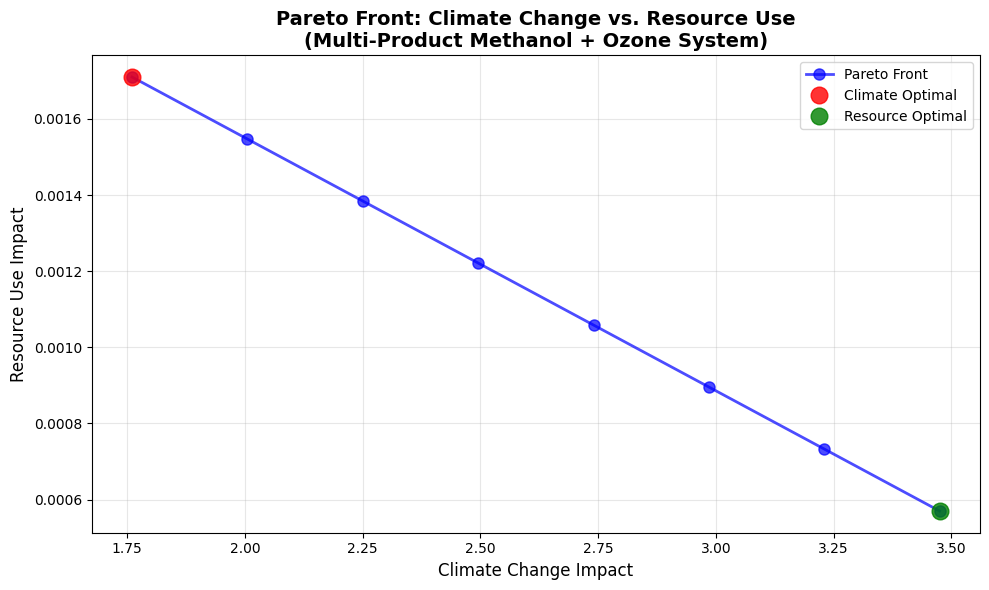

📈 PARETO FRONT ANALYSIS
Number of Pareto points: 8

Climate Change Range:
  Best: 1.7604
  Worst: 3.4753
  Range: 1.7149

Resource Use Range:
  Best: 0.0006
  Worst: 0.0017
  Range: 0.0011


In [31]:
import matplotlib.pyplot as plt

# Extract data for plotting
if pareto_front:
    resource_values = [point[0] for point in pareto_front]
    climate_values = [point[1] for point in pareto_front]
    
    # Create the plot
    plt.figure(figsize=(10, 6))
    
    # Plot Pareto front
    plt.plot(climate_values, resource_values, 'bo-', linewidth=2, markersize=8, 
             label='Pareto Front', alpha=0.7)
    
    # Highlight extreme points
    plt.plot(climate_optimal_cc, climate_optimal_res, 'ro', markersize=12, 
             label='Climate Optimal', alpha=0.8)
    plt.plot(resource_optimal_cc, resource_optimal_res, 'go', markersize=12, 
             label='Resource Optimal', alpha=0.8)
    
    # Formatting
    plt.xlabel('Climate Change Impact', fontsize=12)
    plt.ylabel('Resource Use Impact', fontsize=12)
    plt.title('Pareto Front: Climate Change vs. Resource Use\n(Multi-Product Methanol + Ozone System)', 
              fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("📈 PARETO FRONT ANALYSIS")
    print("=" * 40)
    print(f"Number of Pareto points: {len(pareto_front)}")
    print(f"\nClimate Change Range:")
    print(f"  Best: {min(climate_values):.4f}")
    print(f"  Worst: {max(climate_values):.4f}")
    print(f"  Range: {max(climate_values) - min(climate_values):.4f}")
    print(f"\nResource Use Range:")
    print(f"  Best: {min(resource_values):.4f}")
    print(f"  Worst: {max(resource_values):.4f}")
    print(f"  Range: {max(resource_values) - min(resource_values):.4f}")
    
else:
    print("No feasible Pareto points found")

## 7. Uncertainty Analysis: Monte Carlo Simulation

Real-world systems contain parameter uncertainties that propagate through optimization results. PULPO's Monte Carlo capabilities enable robustness assessment and uncertainty quantification for environmental impact optimization.

**Analysis Objectives:**
- Quantify parameter uncertainty effects on optimal solutions
- Assess result robustness across uncertainty ranges
- Analyze correlation between environmental objectives under uncertainty
- Generate confidence intervals for impact assessments

### 7.1 Uncertainty Worker Configuration

Configure specialized PULPO worker for uncertainty analysis with climate change minimization as primary objective while tracking both impact categories.

In [32]:
# Create uncertainty analysis worker focusing on climate change
methods_uncertainty = {
    "('my project', 'climate change')": 1,
    "('my project', 'resources')": 0,
}

# Initialize uncertainty PULPO worker
pulpo_worker_unc = pulpo.PulpoOptimizer(project, database, methods_uncertainty, directory)
pulpo_worker_unc.get_lci_data()

print("Uncertainty analysis PULPO worker created successfully")
print("Objective: Minimize climate change impact under parameter uncertainty")

Uncertainty analysis PULPO worker created successfully
Objective: Minimize climate change impact under parameter uncertainty


### 7.2 Monte Carlo Parameter Configuration

Configure system parameters for uncertainty analysis:
- **Demand specification**: Multi-product system (1 kg methanol + 2 kg ozone)
- **Technology options**: All electricity, hydrogen, and oxygen alternatives available
- **Constraints**: Unconstrained capacities for computational clarity
- **Uncertainty source**: Parameter sampling from database uncertainty distributions

In [33]:
# Configure same system as before for uncertainty analysis
# Multi-product demand: methanol + ozone
demand_unc = {methanol_process[0]: 1, ozone_process[0]: 2}

# Technology choices (unconstrained for clarity)
choices_unc = {
    "Electricity": {electricity_processes[0]: 1e10, electricity_processes[1]: 1e10},
    "Hydrogen": {hydrogen_processes[0]: 1e10, hydrogen_processes[1]: 1e10},
    "Oxygen": {oxygen_processes[0]: 1e10, oxygen_processes[1]: 1e10},
}

# Lower bounds
lower_bound_unc = {oxygen_byproduct[0]: 0}

print("System configuration for uncertainty analysis:")
print(f"  Demand: {len(demand_unc)} products")
print(f"  Technology choices: {len(choices_unc)} categories")
print(f"  Lower bounds: {len(lower_bound_unc)} constraints")

System configuration for uncertainty analysis:
  Demand: 2 products
  Technology choices: 3 categories
  Lower bounds: 1 constraints


### 7.3 Monte Carlo Execution

Execute Monte Carlo simulation using `solve_MC` function:
1. **Problem instantiation** with specified configuration
2. **Parameter sampling** across multiple iterations from uncertainty distributions
3. **Optimization solving** for each parameter realization
4. **Result collection** across all Monte Carlo iterations

The function automatically handles parameter uncertainty sampling from database distributions.

In [34]:
# Run Monte Carlo simulation
print("🎲 Starting Monte Carlo simulation...")
print("=" * 50)

# Number of Monte Carlo iterations
n_iterations = 500

# Run Monte Carlo analysis
pulpo_worker_unc.instantiate(choices=choices_unc, demand=demand_unc, lower_limit=lower_bound_unc)
mc_results = pulpo_worker_unc.solve_MC(
    n_it=n_iterations
)

print(f"✅ Monte Carlo simulation completed successfully!")
print(f"   Total iterations: {n_iterations}")
print(f"   Results structure: {type(mc_results)}")

# Examine results structure
if hasattr(mc_results, 'keys'):
    print(f"   Available result keys: {list(mc_results.keys())}")
else:
    print(f"   Results type: {type(mc_results)}")
    print(f"   Results shape/length: {len(mc_results) if hasattr(mc_results, '__len__') else 'N/A'}")

🎲 Starting Monte Carlo simulation...
Creating Instance
Instance created
Creating Instance
Instance created
Optimization problem solved using Highspy
Creating Instance
Instance created
Optimization problem solved using Highspy
Creating Instance
Instance created
Optimization problem solved using Highspy
Creating Instance
Instance created
Optimization problem solved using Highspy
Creating Instance
Instance created
Optimization problem solved using Highspy
Creating Instance
Instance created
Optimization problem solved using Highspy
Creating Instance
Instance created
Optimization problem solved using Highspy
Creating Instance
Instance created
Optimization problem solved using Highspy
Creating Instance
Instance created
Creating Instance
Instance created
Optimization problem solved using Highspy
Creating Instance
Instance created
Optimization problem solved using Highspy
Creating Instance
Instance created
Optimization problem solved using Highspy
Creating Instance
Instance created
Optimizatio

### 7.4 Statistical Analysis

Extract and analyze environmental impacts from Monte Carlo simulation results. Calculate statistical measures and assess uncertainty distribution characteristics across both impact categories.

In [35]:
# Extract both climate change and resource impacts from Monte Carlo results

climate_key = "('my project', 'climate change')"
resource_key = "('my project', 'resources')"

if isinstance(mc_results, list) and len(mc_results) > 0:
    print(f"Extracting both climate change and resource impacts from {len(mc_results)} Monte Carlo iterations...")
    
    climate_impacts = []
    resource_impacts = []
    successful_iterations = 0
    
    for i, iteration_result in enumerate(mc_results):
        try:
            # Access both impact values from pyomo result object
            climate_value = iteration_result[climate_key].value
            resource_value = iteration_result[resource_key].value
            
            if climate_value is not None and resource_value is not None:
                climate_impacts.append(climate_value)
                resource_impacts.append(resource_value)
                successful_iterations += 1
        except (KeyError, AttributeError) as e:
            print(f"Warning: Could not extract impacts from iteration {i}: {e}")
            continue
    
    print(f"Successfully extracted impacts from {successful_iterations}/{len(mc_results)} iterations")
    
    if len(climate_impacts) > 0 and len(resource_impacts) > 0:
        # Convert to numpy arrays for analysis
        climate_impacts = np.array(climate_impacts)
        resource_impacts = np.array(resource_impacts)
        
        # Calculate statistical measures for climate change
        climate_mean = np.mean(climate_impacts)
        
        # Calculate statistical measures for resource use
        resource_mean = np.mean(resource_impacts)


Extracting both climate change and resource impacts from 500 Monte Carlo iterations...
Successfully extracted impacts from 500/500 iterations


### 7.5 Uncertainty Visualization

Create comprehensive uncertainty visualization including:
- **Density distributions**: KDE plots showing climate-resource correlations
- **Statistical summaries**: Means, confidence intervals, and correlation coefficients
- **Comparative analysis**: Uncertainty quantification across both environmental objectives

C:\Users\flechtenberg\AppData\Local\Temp\ipykernel_14364\2395788844.py:23: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\flechtenberg\AppData\Local\miniconda3\envs\pulpo-test\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


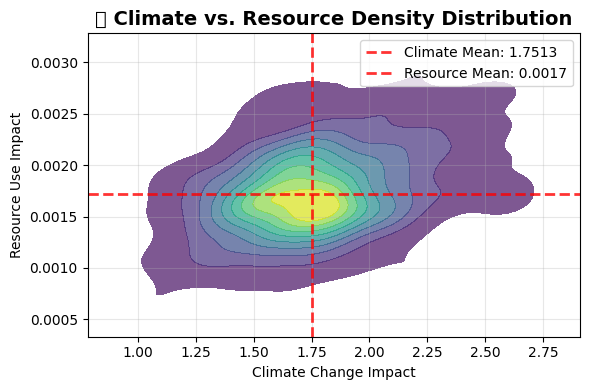

In [36]:
if climate_impacts is not None and resource_impacts is not None and len(climate_impacts) > 0:
    import seaborn as sns
    
    # Create elegant dual-objective uncertainty visualization
    fig, ax1 = plt.subplots(1, 1, figsize=(6, 4))
    
    # 1. Seaborn KDE plot for density distribution
    ax1.set_title('🔗 Climate vs. Resource Density Distribution', fontsize=14, fontweight='bold')
    sns.kdeplot(x=climate_impacts, y=resource_impacts, cmap='viridis', fill=True, 
                thresh=0.02, ax=ax1, alpha=0.7)
    
    # Add mean lines
    ax1.axvline(climate_mean, color='red', linestyle='--', linewidth=2, alpha=0.8, 
                label=f'Climate Mean: {climate_mean:.4f}')
    ax1.axhline(resource_mean, color='red', linestyle='--', linewidth=2, alpha=0.8, 
                label=f'Resource Mean: {resource_mean:.4f}')
    
    ax1.set_xlabel('Climate Change Impact')
    ax1.set_ylabel('Resource Use Impact')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

else:
    print("❌ Cannot create visualization - missing valid impact data for both objectives")

## 8. Custom Optimization Limits

PULPO allows customization of default mathematical bounds used in optimization models. These limits define the feasible range for decision variables and can be adjusted for specific problem requirements or numerical stability.

**Applications for Custom Limits:**
- Numerical stability improvements for specific solvers
- Problem-specific physical constraints
- Computational efficiency optimization
- Specialized optimization domains

### 8.1 Default Behavior

Standard PULPO optimization using default mathematical bounds for baseline comparison.

In [37]:
# Standard optimization with default limits
methods_default = {"('my project', 'climate change')": 1, "('my project', 'resources')": 0}
pulpo_worker_default = pulpo.PulpoOptimizer(project, database, methods_default, directory)
pulpo_worker_default.get_lci_data()

pulpo_worker_default.instantiate(choices=choices_unconstrained, demand=demand, lower_limit=lower_bound)
results_default = pulpo_worker_default.solve()

default_climate = pulpo_worker_default.instance.impacts_calculated["('my project', 'climate change')"].value
default_resources = pulpo_worker_default.instance.impacts_calculated["('my project', 'resources')"].value

print(f"Default limits - Climate: {default_climate:.6f}, Resources: {default_resources:.6f}")

Creating Instance
Instance created
Optimization problem solved using Highspy
Default limits - Climate: 1.760427, Resources: 0.001710


### 8.2 Custom Limits Implementation

Specify custom bounds using the `default_limits` parameter with three optional keys.

In [40]:
# Configure custom limits (more restrictive than defaults)
custom_limits = {
    'lower_bound': -1e15,      # vs. default -1e20
    'upper_bound': 1e15,       # vs. default +1e20
    'upper_inv_bound': 1e20,    # vs. default +1e24
    'lower_inv_bound': -1e20,   # vs. default -1e24
    'lower_imp_bound': -1e20,   # vs. default -1e24
    'upper_imp_bound': 1e20,    # vs. default +1e
}

print("Custom limits configured - more restrictive than defaults")

Custom limits configured - more restrictive than defaults


In [42]:
# Solve with custom limits
pulpo_worker_custom = pulpo.PulpoOptimizer(project, database, methods_default, directory)
pulpo_worker_custom.get_lci_data()

pulpo_worker_custom.instantiate(
    choices=choices_unconstrained, 
    demand=demand, 
    lower_limit=lower_bound,
    default_limits=custom_limits  # Apply custom limits
)

results_custom = pulpo_worker_custom.solve()
custom_climate = pulpo_worker_custom.instance.impacts_calculated["('my project', 'climate change')"].value
custom_resources = pulpo_worker_custom.instance.impacts_calculated["('my project', 'resources')"].value

print(f"Custom limits - Climate: {custom_climate:.6f}, Resources: {custom_resources:.6f}")
print(f"Difference: {abs(custom_climate-default_climate):.2e} (should be minimal for this problem)")

Creating Instance
Instance created
Optimization problem solved using Highspy
Custom limits - Climate: 1.760427, Resources: 0.001710
Difference: 0.00e+00 (should be minimal for this problem)


### 8.3 Overly Restrictive Limits

Demonstration of optimization failure when limits are set too restrictively.

In [43]:
# Very restrictive limits (will likely cause failure)
restrictive_limits = {'lower_bound': -0.1, 'upper_bound': 0.1, 'upper_inv_bound': 0.1, 'lower_inv_bound': -0.1, 'lower_imp_bound': -0.1, 'upper_imp_bound': 0.1}

try:
    pulpo_worker_restrictive = pulpo.PulpoOptimizer(project, database, methods_default, directory)
    pulpo_worker_restrictive.get_lci_data()
    
    pulpo_worker_restrictive.instantiate(
        choices=choices_unconstrained, 
        demand=demand, 
        lower_limit=lower_bound,
        default_limits=restrictive_limits
    )
    
    results_restrictive = pulpo_worker_restrictive.solve()
    print("✅ Unexpected success!")
    
except Exception as e:
    print(f"❌ Optimization failed as expected: {type(e).__name__}")
    print("💡 Demonstrates importance of appropriate limit selection")

Creating Instance
Instance created
❌ Optimization failed as expected: RuntimeError
💡 Demonstrates importance of appropriate limit selection
